In [36]:
from bauer.models import MagnitudeComparisonModel, MagnitudeComparisonLapseModel, MagnitudeComparisonLapseRegressionModel
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bauer.utils.data import load_garcia2022
from bauer.utils.plotting import plot_subjectwise_parameters

In this notebook we explore models that allow for _lapses_: trials on which the subject does not process any information and just responds completely randomly.

see, e.g.:
 * Green, D. M. (1990). Stimulus Selection in Adaptive Psychophysical Procedures. Journal of the Acoustical Society of America, 87(6), 2662-2674.
 * Wichmann, F. A., & Hill, N. J. (2001a). The psychometric function: I. Fitting, sampling, and goodness of fit. Perception & Psychophysics, 63(8), 1293-1313. https://doi.org/10.3758/Bf03194544

# Show some predictions of lapse model

In [9]:
model = MagnitudeComparisonLapseModel()

In [10]:
paradigm = model._get_example_paradigm(n_fractions=25)
paradigm['log(n2/n1)'] = np.log(paradigm['n2'] / paradigm['n1'])

In [19]:
parameters_lapses5 = {'n1_evidence_sd':0.1, 'n2_evidence_sd':0.1, 'p_lapse':0.1}
parameters_lapses1 = {'n1_evidence_sd':0.1, 'n2_evidence_sd':0.1, 'p_lapse':0.2}
parameters_no_lapses = {'n1_evidence_sd':0.1, 'n2_evidence_sd':0.1, 'p_lapse':0.0}

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


(0.0, 1.0)

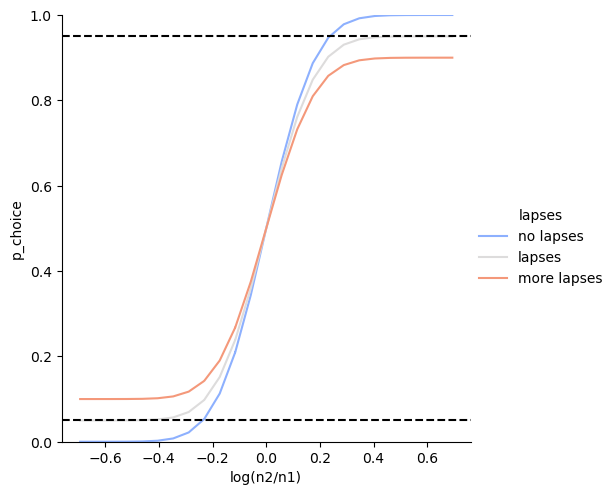

In [20]:
predictions_lapses5 = model.predict(paradigm, parameters_lapses5)
predictions_lapses1 = model.predict(paradigm, parameters_lapses1)
predictions_no_lapses = model.predict(paradigm, parameters_no_lapses)
predictions = pd.concat([predictions_lapses5, predictions_lapses1, predictions_no_lapses], keys=['lapses', 'more lapses', 'no lapses'], names=['lapses'],)


sns.relplot(x='log(n2/n1)', y='p_choice', data=predictions, kind='line', ci=None, hue='lapses', palette=sns.color_palette('coolwarm', 3),
            hue_order=['no lapses', 'lapses', 'more lapses'])
plt.axhline(0.05, c='k', ls='--')
plt.axhline(0.95, c='k', ls='--')
plt.ylim(0, 1)

# Fit to real data

In [21]:
df = load_garcia2022()

In [22]:
model = MagnitudeComparisonLapseModel(data=df)

model.build_estimation_model()

idata = model.sample(target_accept=.9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, p_lapse_mu_untransformed, p_lapse_sd, p_lapse_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 164 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


In [23]:
model.get_subjectwise_parameter_estimates(idata).corr()

parameter,n1_evidence_sd,n2_evidence_sd,p_lapse
parameter,,,
n1_evidence_sd,1.000000,-0.008429,0.025497
n2_evidence_sd,-0.008429,1.000000,-0.003573
p_lapse,0.025497,-0.003573,1.000000


          p_lapse          
          hdi_low  hdi_high
subject                    
1        0.003717  0.050555
2        0.003572  0.059785
3        0.002899  0.060292
4        0.005626  0.077389
5        0.010470  0.083818
...           ...       ...
60       0.002550  0.038366
61       0.006738  0.077198
62       0.005990  0.075885
63       0.004010  0.063941
64       0.003030  0.056231

[64 rows x 2 columns]


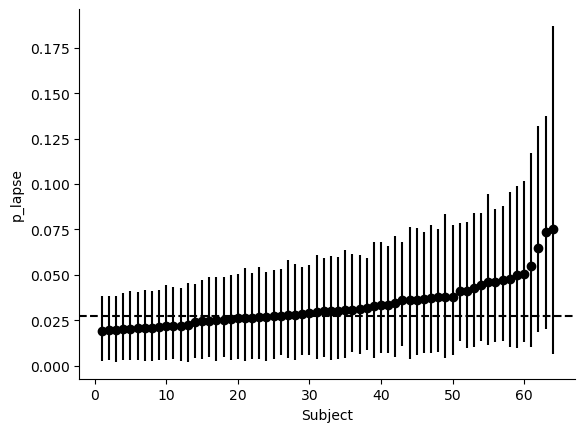

In [24]:
plot_subjectwise_parameters(idata, 'p_lapse', sort_subjects=True)

# Fit to RegressionModel

Let's see if the number of lapses is different in the second part of the experiment...

In [25]:
model = MagnitudeComparisonLapseRegressionModel(df.reset_index('run'), regressors={'p_lapse':'0 + C(run)'})


model.build_estimation_model()

In [26]:
idata = model.sample(1000, 1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_mu, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu, n2_evidence_sd_sd, n2_evidence_sd_offset, p_lapse_mu, p_lapse_sd, p_lapse_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 461 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 75 divergences after tuning. Increase `target_accept` or reparameterize.


Subjects seem to have slightly more lapses around run 3, when they start getting bored...

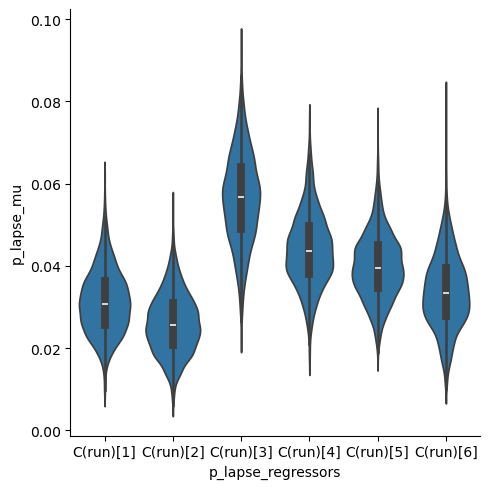

In [28]:

from bauer.utils.math import softplus_np
tmp = softplus_np(idata.posterior['p_lapse_mu'].to_dataframe())

sns.catplot(x='p_lapse_regressors', y='p_lapse_mu', data=tmp.reset_index(), kind='violin')

Indeed we have quite some convincing evidence that the lapse rate is higher
in the third run compared to the second run.

0.01225

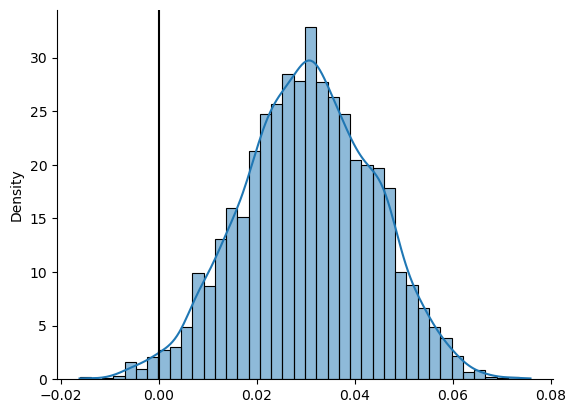

In [35]:
sns.histplot(tmp.unstack(-1)['p_lapse_mu']['C(run)[3]'] - tmp.unstack(-1)['p_lapse_mu']['C(run)[2]'],
             kde=True, stat='density')
plt.axvline(0.0, c='k')
sns.despine()


((tmp.unstack(-1)['p_lapse_mu']['C(run)[3]'] - tmp.unstack(-1)['p_lapse_mu']['C(run)[2]']) < 0.0).mean()

## Model comparison

Let's see if we can find evidence that a model with lapses is more
probable than one without, given the data.

In [38]:
model1 = MagnitudeComparisonModel()
model2 = MagnitudeComparisonLapseModel()

model1.build_estimation_model(df)
model2.build_estimation_model(df)

idata1 = model1.sample(1000, 1000)
idata2 = model2.sample(1000, 1000)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 79 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, p_lapse_mu_untransformed, p_lapse_sd, p_lapse_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 146 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 67 divergences after tuning. Increase `target_accept` or reparameterize.


In [40]:
import pymc as pm

In [42]:
pm.compute_log_likelihood?

Signature:
pm.compute_log_likelihood(
    idata: arviz.data.inference_data.InferenceData,
    *,
    var_names: Optional[Sequence[str]] = None,
    extend_inferencedata: bool = True,
    model: Optional[pymc.model.core.Model] = None,
    sample_dims: Sequence[str] = ('chain', 'draw'),
    progressbar=True,
)
Docstring:
Compute elemwise log_likelihood of model given InferenceData with posterior group

Parameters
----------
idata : InferenceData
    InferenceData with posterior group
var_names : sequence of str, optional
    List of Observed variable names for which to compute log_likelihood. Defaults to all observed variables
extend_inferencedata : bool, default True
    Whether to extend the original InferenceData or return a new one
model : Model, optional
sample_dims : sequence of str, default ("chain", "draw")
progressbar : bool, default True

Returns
-------
idata : InferenceData
    InferenceData with log_likelihood group
File:      ~/mambaforge/lib/python3.10/site-packages/pymc/s

In [46]:
with model1.estimation_model:
    pm.compute_log_likelihood(idata1)

with model2.estimation_model:
    pm.compute_log_likelihood(idata2)

In [47]:
import arviz as az

comparison = az.compare({'Base model': idata1, 'Lapse model': idata2})


/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:805: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_comp.loc[val] = (
/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/stats/stats.py:309: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'log' has dtype 

Clearly, the lapse model fits a lot better than the base model,
even when controlling for the larger number of effective parameters (~104 vs ~86).

/Users/gdehol/mambaforge/lib/python3.10/site-packages/arviz/plots/backends/matplotlib/compareplot.py:87: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale = comp_df["scale"][0]


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

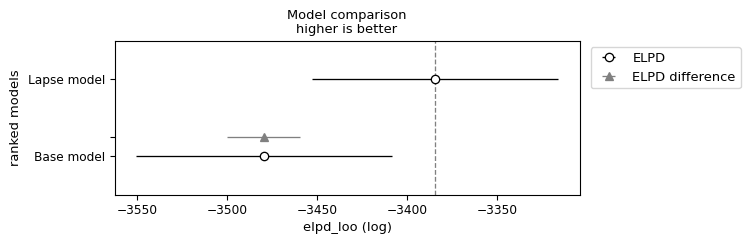

In [48]:
az.plot_compare(comparison)

# Risk model

We can also apply the lapse model to risky choice!

In [54]:
from bauer.models import RiskLapseRegressionModel

In [63]:
# We need 'format' as a column so we can put it in our design matrix.
df = load_garcia2022(task='risk').reset_index('format')

In [65]:
model = RiskLapseRegressionModel(df,
                                 regressors={'evidence_sd':'format'},
                                   prior_estimate='shared', fit_seperate_evidence_sd=False)

In [66]:
model.build_estimation_model(df)

In [67]:
idata = model.sample(1000, 1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [evidence_sd_mu, evidence_sd_sd, evidence_sd_offset, prior_mu_mu, prior_mu_sd, prior_mu_offset, prior_std_mu, prior_std_sd, prior_std_offset, p_lapse_mu, p_lapse_sd, p_lapse_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14047 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 160 divergences after tuning. Increase `target_accept` or reparameterize.


In [73]:
idata.posterior['evidence_sd'].to_dataframe()

evidence_sd
chain draw subject evidence_sd_regressors             
0     0    1       Intercept                 -1.768858
                   format[T.symbolic]        -0.972069
           2       Intercept                 -2.020684
                   format[T.symbolic]        -1.226997
           3       Intercept                 -0.914029
...                                                ...
3     999  62      format[T.symbolic]        -0.285322
           63      Intercept                 -2.069316
                   format[T.symbolic]        -0.018304
           64      Intercept                 -1.568677
                   format[T.symbolic]        -0.058652

[512000 rows x 1 columns]

Most subjects show no lapses!

          p_lapse          
          hdi_low  hdi_high
subject                    
1        0.001883  0.056093
2        0.012732  0.069897
3        0.000058  0.053450
4        0.000266  0.048459
5        0.001290  0.390811
...           ...       ...
60       0.009400  0.065892
61       0.000281  0.034466
62       0.000721  0.041850
63       0.002171  0.059191
64       0.000165  0.040709

[64 rows x 2 columns]


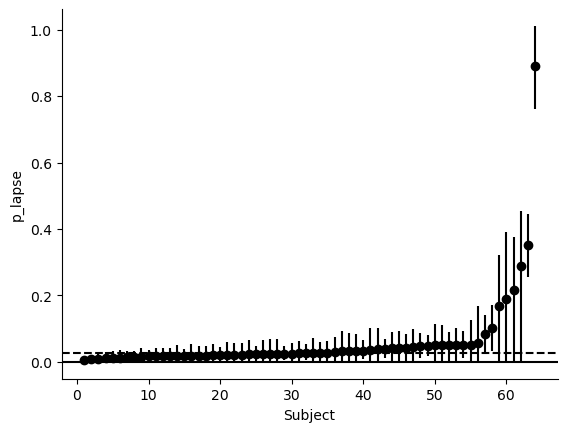

In [86]:
plot_subjectwise_parameters(idata, 'p_lapse', sort_subjects=True, transform='softplus')

plt.axhline(0.0, c='k', ls='-')

In [90]:
pars = model.get_subjectwise_parameter_estimates(idata)

pars.xs('Intercept', 0, 'evidence_sd_regressors').groupby('subject').mean().corr()

parameter,evidence_sd,prior_mu,prior_std,p_lapse
parameter,,,,
evidence_sd,1.000000,0.023799,0.196912,0.225176
prior_mu,0.023799,1.000000,0.034346,0.014699
prior_std,0.196912,0.034346,1.000000,0.139000
p_lapse,0.225176,0.014699,0.139000,1.000000


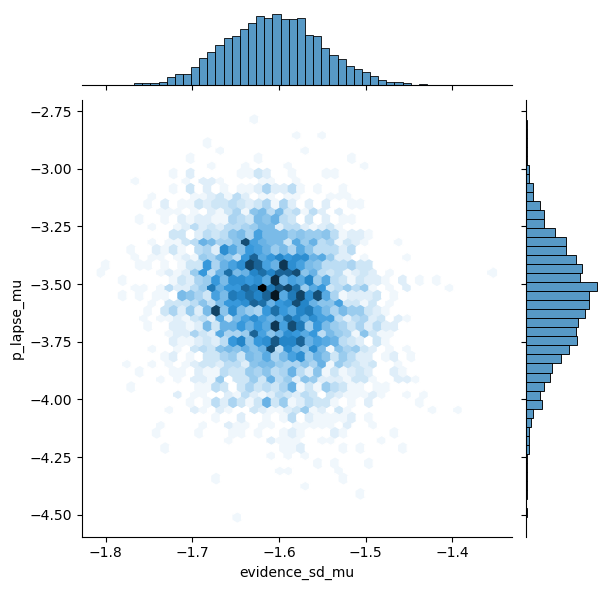

In [95]:
sns.jointplot(x='evidence_sd_mu', y='p_lapse_mu', data=idata.posterior[['evidence_sd_mu', 'p_lapse_mu']].to_dataframe().xs('Intercept', 0, 'evidence_sd_regressors'), kind='hex')

In [109]:
evidence_sd_non_symbolic = idata.posterior.evidence_sd.to_dataframe().unstack(-1)[('evidence_sd', 'Intercept')]
evidence_sd_symbolic = idata.posterior.evidence_sd.to_dataframe().unstack(-1).sum(1)
evidence_sd = softplus_np(pd.concat((evidence_sd_non_symbolic, evidence_sd_symbolic), keys=['non-symbolic', 'symbolic'], names=['format']).to_frame('evidence_sd'))

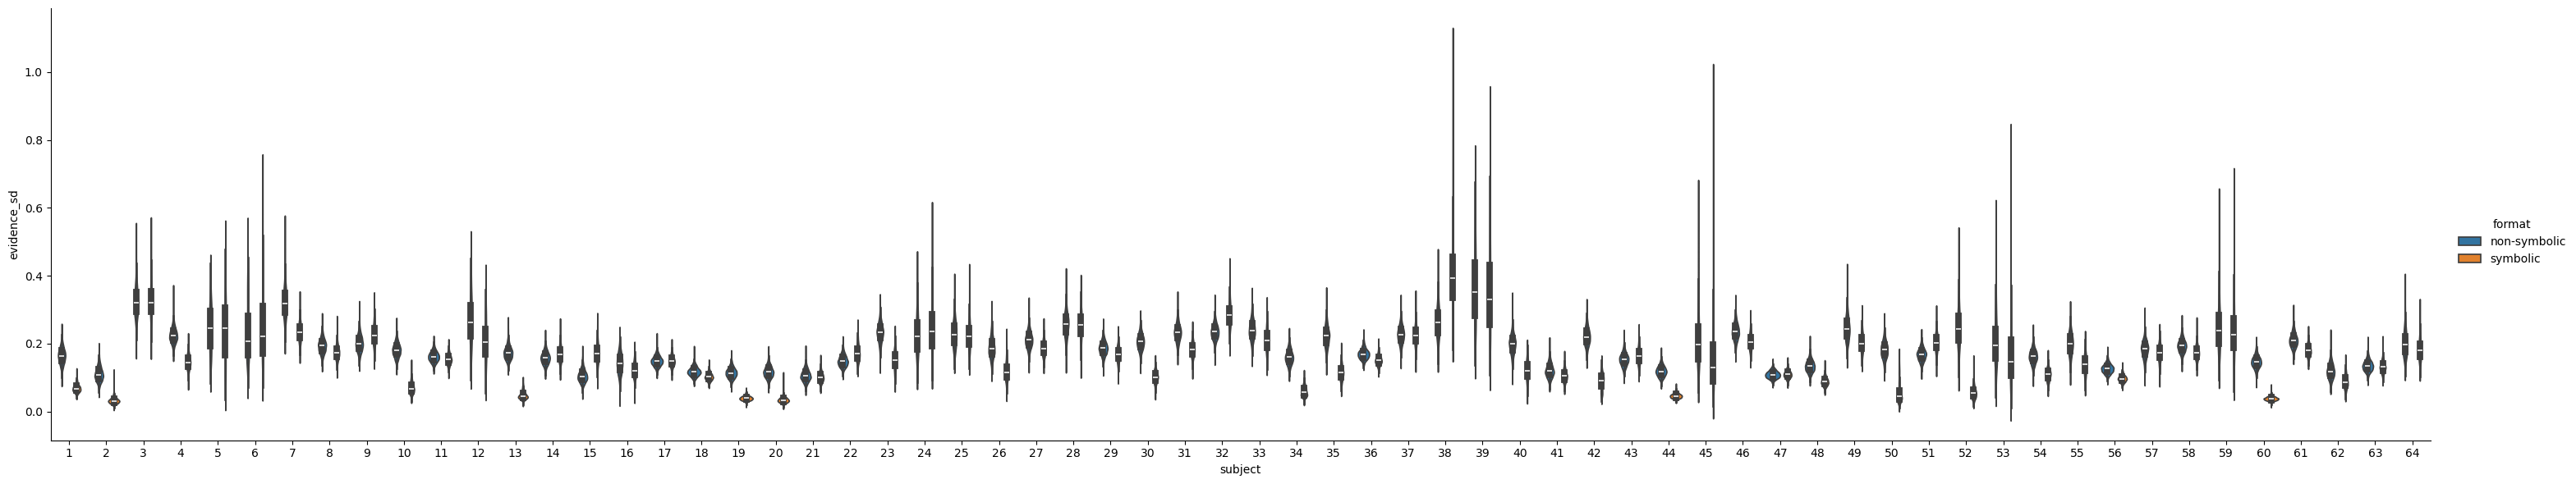

In [112]:
sns.catplot(x='subject', y='evidence_sd', hue='format', data=evidence_sd.reset_index(), kind='violin', aspect=5., height=6)

In [117]:
pars = model.get_subjectwise_parameter_estimates(idata, parameters={'p_lapse':{}})

In [125]:
softplus_np(pars).groupby('subject').mean().sort_values('p_lapse')

parameter,p_lapse
subject,
53,0.007024
18,0.007625
56,0.009272
11,0.011360
36,0.011722
...,...
5,0.189708
12,0.215222
6,0.287511


In [ ]:
s